#### Loading packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#### Setting root directory path

In [2]:
ROOT = r'C:\Users\PC_DS_ECON_5\Desktop\data-analytics-python'


#### Data source used: NLSY97

The NLSY97 is a `longitudinal` (i.e. `panel`) survey of individuals born between 1980 and 1984. The first round of data collection took place in 1997 and was followed by additional survey rounds every one or two years.


#### Loading data

Reminder: We need the `pyarrow` package to import a `.parquet` datafile.

In [3]:
nlsy97_income_hours_all_df = pd.read_parquet(ROOT + '/data/nlsy97_income_hours_all_df.parquet')
nlsy97_additional_vars_df = pd.read_parquet(ROOT + '/data/nlsy97_additional_vars_df.parquet')


#### Dictionary of variable labels

In [7]:
long_varlabels_dict = {
    'gender': 'Gender',
    'ethnicity': 'Ethnicity',
    'educ': 'Highest Grade Completed',
    'degree': 'Highest Degree Earned',
    'meduc_bio': 'Highest Grade Completed (Biological Mother)',
    'meduc_res': 'Highest Grade Completed (Residential Mother)',
    'feduc_bio': 'Highest Grade Completed (Biological Father)',
    'feduc_res': 'Highest Grade Completed (Residential Father)',
    'educ_num': 'Inferred Years of Education',
    'educ_cat': 'Highest Degree Earned',
    'meduc_bio_num': 'Inferred Years of Education (Biological Mother)',
    'meduc_res_num': 'Inferred Years of Education (Residential Mother)',
    'feduc_bio_num': 'Inferred Years of Education (Biological Father)',
    'feduc_res_num': 'Inferred Years of Education (Residential Father)',
    'meduc_bio_cat': 'Inferred Degree (Biological Mother)',
    'meduc_res_cat': 'Inferred Degree (Residential Mother)',
    'feduc_bio_cat': 'Inferred Degree (Biological Father)',
    'feduc_res_cat': 'Inferred Degree (Residential Father)',
    'hh_yinc_1997': 'Household Income in 1997',
    'hh_yinc_source_1997': 'Source of Household Income in 1997', 
    'hh_net_worth_1997': 'Household Net Worth in 1997'
}


short_varlabels_dict = {
    'gender': 'Gender',
    'ethnicity': 'Ethnicity',
    'educ': 'Highest Grade Completed',
    'degree': 'Highest Degree Earned',
    'meduc_bio': 'Highest Grade Compl. (Biol. Mother)',
    'meduc_res': 'Highest Grade Compl. (Resid. Mother)',
    'feduc_bio': 'Highest Grade Compl. (Biol. Father)',
    'feduc_res': 'Highest Grade Compl. (Resid. Father)',
    'educ_num': 'Inferred Years of Educ.',
    'educ_cat': 'Highest Degree Earned',
    'meduc_bio_num': 'Inferred Years of Educ. (Biol. Mother)',
    'meduc_res_num': 'Inferred Years of Educ. (Resid. Mother)',
    'feduc_bio_num': 'Inferred Years of Educ. (Biol. Father)',
    'feduc_res_num': 'Inferred Years of Educ. (Resid. Father)',
    'meduc_bio_cat': 'Inferred Highest Degree (Biol. Mother)',
    'meduc_res_cat': 'Inferred Highest Degree (Resid. Mother)',
    'feduc_bio_cat': 'Inferred Highest Degree (Biol. Father)',
    'feduc_res_cat': 'Inferred Highest Degree (Resid. Father)',
    'hh_yinc_1997': 'HH Income in 1997',
    'hh_yinc_source_1997': 'Source of HH Income in 1997', 
    'hh_net_worth_1997': 'HH Net Worth in 1997'
}

#### Intergenerational Transmission of Educational Attainment (mother/father)

In the NLSY97 there are two commonly used measures of educational attainment:

 - highest grade completed (here the variable `educ`)
 - highest degree earned (here the variable `degree`)

The variable `educ` records the highest grade or year of education completed, while `degree` records the highest educational credential earned (e.g. high school diploma, bachelor's degree, master's degree).

For the parents of respondents, only a measure corresponding to highest grade completed is available. The relevant variables are:

 - highest grade completed by the biological mother (`meduc_bio`)
 - highest grade completed by the residential mother (`meduc_res`)
 - highest grade completed by the biological father (`feduc_bio`)
 - highest grade completed by the residential father (`feduc_res`)


Let us first look at the content of the `educ`-type variables. These are ordered categorical variables.

In [4]:
nlsy97_additional_vars_df['educ'].dtype

CategoricalDtype(categories=['1st grade', '2nd grade', '3rd grade', '4th grade',
                  '5th grade', '6th grade', '7th grade', '8th grade',
                  '9th grade', '10th grade', '11th grade', '12th grade',
                  '1st year college', '2nd year college', '3rd year college',
                  '4th year college', '5th year college', '6th year college',
                  '7th year college', '8th year college or more'],
, ordered=True, categories_dtype=str)

Let us plot the histogram of highest grade completed for participants, their mothers, their fathers for the representative sub-sample (`sample='Cross-sectional'`).

In [5]:
nlsy97_additional_vars_df['sample'].value_counts()

sample
Cross-sectional    6748
Oversample         2236
Name: count, dtype: int64[pyarrow]

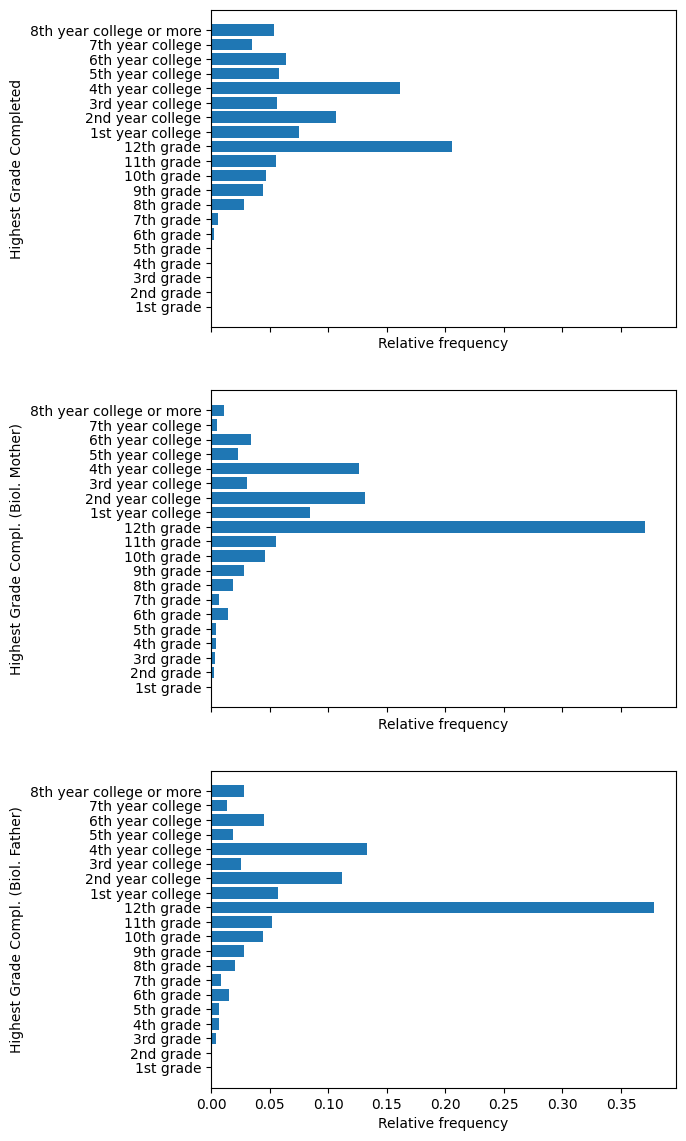

In [8]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6,14), sharex=True, sharey=True)
varnames = ['educ', 'meduc_bio', 'feduc_bio']

for i, varname in enumerate(varnames):
    df = nlsy97_additional_vars_df.copy()
    df = (
        df
            .loc[df['sample'].eq('Cross-sectional'), varname]
            .value_counts(normalize=True)
            .reset_index()
            .sort_values(varname)
            .reset_index(drop=True)
    )
    axs[i].barh(y=df[varname].astype(str), width=df['proportion'], height=0.8)
    axs[i].set_xlabel('Relative frequency')
    axs[i].set_ylabel(short_varlabels_dict[varname])

There are corresponding variables (`educ_num`, `meduc_bio_num`, `meduc_res_num`, `feduc_bio_num`, `feduc_res_num`) that translate these ordered categorical variables into a numerical variable (years of education).



In [9]:
varname = 'educ'
df = nlsy97_additional_vars_df.copy()
df = (
    df[[varname, varname + '_num']]
        .loc[df['sample'].eq('Cross-sectional'),:]
        .value_counts(normalize=True)
        .reset_index()
        .sort_values([varname, varname + '_num'])
        .reset_index(drop=True)
        .copy()
)
df = df.loc[df['proportion'].ne(0),:].copy()
df

,educ,educ_num,proportion
17,2nd grade,2,0.000150
69,5th grade,5,0.000750
87,6th grade,6,0.002850
105,7th grade,7,0.005551
123,8th grade,8,0.028503
141,9th grade,9,0.044704
159,10th grade,10,0.046805
177,11th grade,11,0.055206
195,12th grade,12,0.205371
213,1st year college,13,0.074857


The `degree` variable exists only for the study participants, but not for their parents. It is an ordered categorical variable.

In [10]:
df = nlsy97_additional_vars_df.copy()
df['degree'].dtype


CategoricalDtype(categories=['No degree', 'GED', 'High school', 'Junior college',
                  'Bachelor', 'Master', 'Professional', 'PhD'],
, ordered=True, categories_dtype=str)

In [ ]:
df0 = df.loc[
    df['educ'].notna() & df['degree'].isna(),
    ['educ', 'degree']
].value_counts(dropna=False).reset_index().copy()

df0 = df0.loc[df0['count'] > 0,:]

df0.sort_values('educ')

Let us recode participants' and parents' highest grade completed into broader categories.

For participants, we use the following rule:

$$
educ\_cat = 
\begin{cases}
\text{Less than High School} & \text{if } degree = \text{No degree} \text{ or } degree = \text{GED}\\
\text{High School} & \text{if } degree = \text{High school} \text{ and } educ\_num \leq 12\\
\text{Some College} & \text{if } (degree = \text{High school} \text{ and } educ\_num > 12) \text{ or } degree = \text{Junior college}\\
\text{Bachelor Plus} & \text{if } degree \in \{\text{Bachelor}, \text{Master}, \text{Professional}, \text{PhD}\}
\end{cases}
$$

For parents, we use the following rule:

$$
[m/f]educ\_cat = 
\begin{cases}
\text{Less than High School} & \text{if } [m/f]educ\_num \leq 11\\
\text{High School} & \text{if } [m/f]educ\_num = 12\\
\text{Some College} & \text{if } [m/f]educ\_num \in [13,15] \\
\text{Bachelor Plus} & \text{if } [m/f]educ\_num \geq 16
\end{cases}
$$



In [11]:
df = nlsy97_additional_vars_df.copy()
varnames = ['meduc_bio', 'meduc_res', 'feduc_bio', 'feduc_res']
categories = ['Less than High School', 'High School', 'Some College', 'Bachelor Plus']
for varname in varnames:
    df[varname + '_cat'] = pd.NA 
    df.loc[df[varname + '_num'].lt(12), varname + '_cat'] = categories[0]
    df.loc[df[varname + '_num'].eq(12), varname + '_cat'] = categories[1]
    df.loc[df[varname + '_num'].gt(12) & df[varname + '_num'].lt(16), varname + '_cat'] = categories[2]
    df.loc[df[varname + '_num'].ge(16), varname + '_cat'] = categories[3]
    df[varname + '_cat'] = pd.Categorical(df[varname + '_cat'], categories=categories, ordered=True)


df['educ_cat'] = pd.NA
df.loc[df['degree'].eq('No degree'), 'educ_cat'] = categories[0]
df.loc[df['degree'].eq('GED'), 'educ_cat'] = categories[0]
df.loc[df['degree'].eq('High school') & df['educ_num'].le(12), 'educ_cat'] = categories[1]
df.loc[df['degree'].eq('High school') & df['educ_num'].gt(12), 'educ_cat'] = categories[2]
df.loc[df['degree'].eq('Junior college'), 'educ_cat'] = categories[2]
df.loc[df['degree'].eq('Bachelor'), 'educ_cat'] = categories[3]
df.loc[df['degree'].eq('Master'), 'educ_cat'] = categories[3]
df.loc[df['degree'].eq('Professional'), 'educ_cat'] = categories[3]
df.loc[df['degree'].eq('PhD'), 'educ_cat'] = categories[3]
df['educ_cat'] = pd.Categorical(df['educ_cat'], categories=categories, ordered=True)

nlsy97_additional_vars_df = df.copy()        

In [12]:
nlsy97_additional_vars_df['educ_cat'].dtype

CategoricalDtype(categories=['Less than High School', 'High School', 'Some College',
                  'Bachelor Plus'],
, ordered=True, categories_dtype=str)

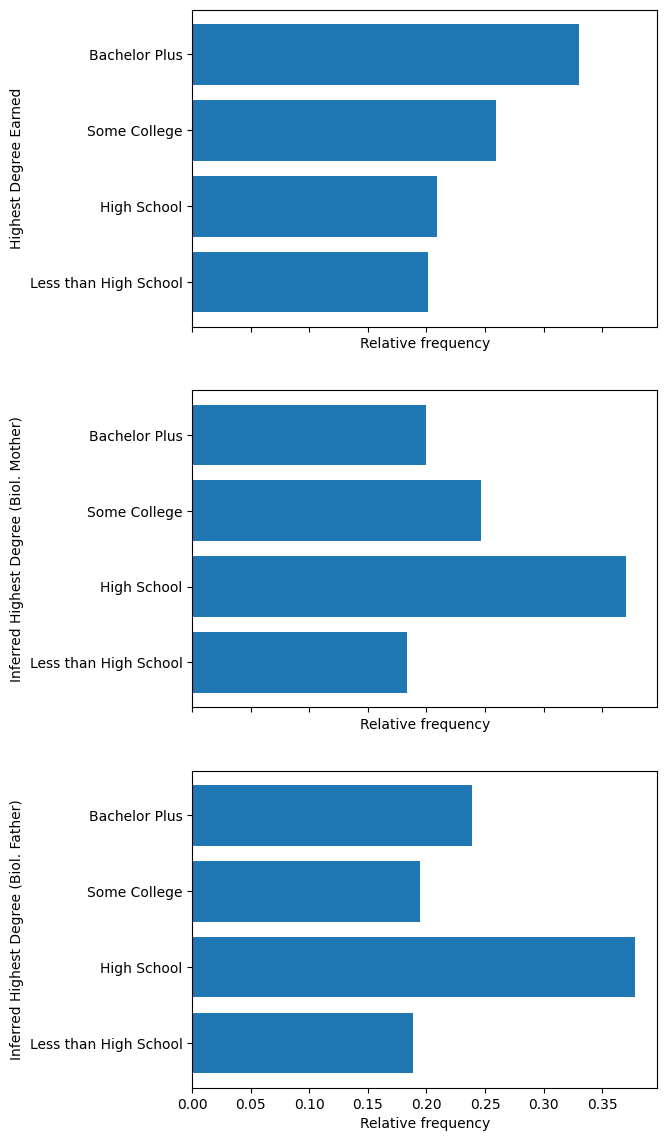

In [13]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6,14), sharex=True, sharey=True)
varnames = ['educ_cat', 'meduc_bio_cat', 'feduc_bio_cat']

for i, varname in enumerate(varnames):
    df = nlsy97_additional_vars_df.copy()
    df = (
        df
            .loc[df['sample'].eq('Cross-sectional'), varname]
            .value_counts(normalize=True)
            .reset_index()
            .sort_values(varname)
            .reset_index(drop=True)
    )
    axs[i].barh(y=df[varname].astype(str), width=df['proportion'], height=0.8)
    axs[i].set_xlabel('Relative frequency')
    axs[i].set_ylabel(short_varlabels_dict[varname])

In [ ]:
df = nlsy97_additional_vars_df.copy()
varnames = ['educ_cat', 'meduc_bio_cat', 'feduc_bio_cat']
plot_df = pd.DataFrame()
for varname in varnames:

    tmp = (
        df
            .loc[df['sample'].eq('Cross-sectional'), varname]
            .value_counts(normalize=True)
            .rename('proportion')
            .reset_index()
            .copy()
    )

    tmp['varname'] = varname 
    tmp['varlabel'] = short_varlabels_dict[varname]
    tmp['category'] = tmp[varname]
    tmp = tmp.drop(columns=varname)

    plot_df = pd.concat([plot_df, tmp], ignore_index=True)

plot_df = plot_df.sort_values(by=['varname', 'category']).reset_index(drop=True).copy()
plot_df['cumulative_proportion_below'] = plot_df.groupby('varname')['proportion'].cumsum() - plot_df['proportion']

categories = plot_df['category'].sort_values().drop_duplicates().to_list()

fig, ax = plt.subplots(figsize=(8, 3))

for category in categories:

    plot_df_cat = plot_df.loc[plot_df['category'].eq(category), :].sort_values(by=['varname']).copy()
    ax.barh(
        y=plot_df_cat['varlabel'],
        width=plot_df_cat['proportion'],
        left=plot_df_cat['cumulative_proportion_below'],
        label=category
    )

ax.set_xlabel('Relative frequency')
ax.legend(title='Education category', loc='center', bbox_to_anchor=(-0.5, -0.15))

Our main objective is intergenerational transmission of educational attainment.

##### Distribution of highest degree earned by parents' inferred highest degree earned.

Our target object of interest could be the probability distribution of highest degree earned conditional on each parent's inferred highest degree.

$$
\mathbb{P}[educ\_cat \ |\ \ meduc\_cat ]
$$

$$
\mathbb{P}[educ\_cat \ |\ \ feduc\_cat ]
$$

These are conditional probabilities. In our observed data, we can compute the corresponding conditional relative frequencies.


$$
\mathbb{P}[Y|X]
$$
where $Y$ is the outcome variable and $X$ is the conditioning variable


Statistical independence:
$$
\mathbb{P}[Y|X] =  \mathbb{P}[Y]
$$
strong measure of unrelatedness between variables

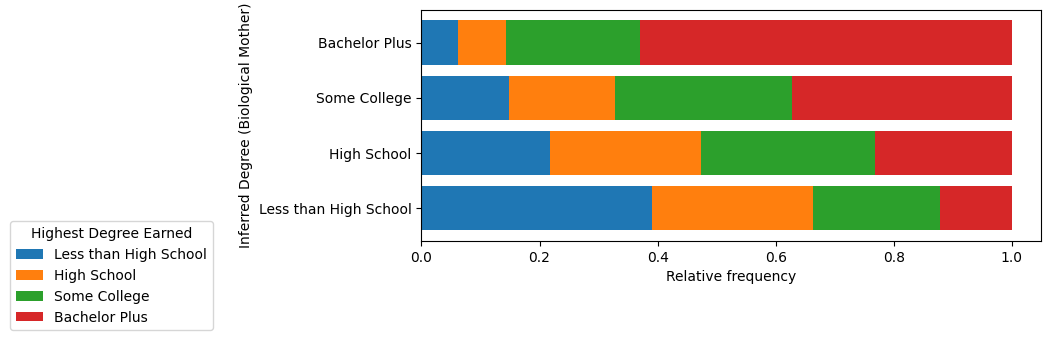

In [17]:
mdf = nlsy97_additional_vars_df.copy()
# conditioning variable parent educational attainment
conditioning_var = 'meduc_bio_cat'
# outcome variable child educational attainment
outcome_var = 'educ_cat'

df_subset = df[[outcome_var, conditioning_var]].copy()

# conditional relative frequencies
plot_df = df_subset.groupby(conditioning_var).value_counts(subset=[outcome_var], normalize=True).reset_index().sort_values(by=[conditioning_var, outcome_var]).reset_index(drop=True).copy()

# cumulative proportions below -> where each bar segment begins 
plot_df['cumulative_proportion_below'] = (
    plot_df
        # within each value of parent education
        .groupby(conditioning_var)['proportion']
        # for each value V of child education
        # share of observations with level L < V 
        .cumsum() - plot_df['proportion']

)
# collecting categories / levels (distinct values) for the outcomes variable 
outcome_var_categories = plot_df[outcome_var].sort_values().drop_duplicates().to_list()

fig, ax = plt.subplots(figsize=(8, 3))

# iterating over the values of child education
for outcome_var_cat in outcome_var_categories:
   
    # restriction by outcome variable value
    plot_df_cat = plot_df.loc[plot_df[outcome_var].eq(outcome_var_cat), :].sort_values(by=[conditioning_var]).copy()
    
    ax.barh(
        # vertical axis: conditioning variable / parent education
        y=plot_df_cat[conditioning_var],
        # horizontal axis: stacked proportions of observations associated with distinct values of the outcome variable
        width=plot_df_cat['proportion'],
        left=plot_df_cat['cumulative_proportion_below'],
        label=outcome_var_cat
    )

ax.set_xlabel('Relative frequency')
ax.set_ylabel(long_varlabels_dict[conditioning_var])
# colour coding
ax.legend(title=short_varlabels_dict[outcome_var], loc='center', bbox_to_anchor=(-0.5, -0.15))




#### Intergenerational Income Mobility

Let us now investigate distribution of participants' 2023 income quintile (in the last observed year when participants are about 40 years old) conditional on the income quintile of their household income in 1997 (when participants are between 13 and 17 years old).


Adding income data from 2023 to the dataframe with the other variables:

In [18]:
# dataframe with income and hours
incomes_df = nlsy97_income_hours_all_df.copy()

incomes_df = (
    incomes_df
        # select rows (year = 2023) and columns (id, income, hours)
        .loc[incomes_df['year'].eq(2023), ['person_id', 'yinc', 'yhours']]
        # rename the income and hours variables
        .rename(columns={'yinc': 'yinc_2023', 'yhours': 'yhours_2023'})
        .copy()
)

# merging with the dataframe containing the other variables
incomes_df = pd.merge(left=nlsy97_additional_vars_df, # df with other variables
                      right=incomes_df, # df just created
                      on='person_id', # person id (uniqeness should normally be checked)
                      how='left') # left-join (keep all observations from left, add only matching observations from right)



Group observations by income rank into five equal groups (in ascending order)
 - by income rank in 1997 (parental income rank around the age of 15)
 - by income rank in 2023 (child income rank around the age of 40)



For both income variables, let us create five income quantile groups based on the income quantiles:
 - first quintile: $[Q(0), Q(0.2)]$ (between the 0% and the 20% point-quantile)
 - second quintile: $(Q(0.2), Q(0.4)]$ (between the 20% and the 40% point-quantile)
 - third quintile: $(Q(0.4), Q(0.6)]$ (between the 40% and the 60% point-quantile)
 - fourth quintile: $(Q(0.6), Q(0.8)]$ (between the 60% and the 80% point-quantile)
 - fifth quintile: $(Q(0.8), Q(1)]$ (between the 80% and the 100% point-quantile)


In [20]:
# We have variables hh_yinc_1997 (household income), yinc_2023 (labor income)
# Income concept is a litte different
# Objective: hh_yinc_1997_Q (parent income quintile),  yinc_2023_Q (income quintile in 2023) 
 
df = incomes_df.copy()

dfs = {}

dfs['hh_yinc_1997'] = df.loc[df['hh_yinc_source_1997'].eq('Parent') & df['hh_yinc_1997'].notna() & df['sample'].eq('Cross-sectional'), ['person_id', 'hh_yinc_1997']].copy()
dfs['yinc_2023'] = df.loc[df['yinc_2023'].notna() & df['sample'].eq('Cross-sectional'), ['person_id', 'yinc_2023']].copy()
quintile_labels = ['1st Quintile', '2nd Quintile', '3rd Quintile', '4th Quintile', '5th Quintile']

for varname in ['hh_yinc_1997', 'yinc_2023']:

    df = dfs[varname].copy()
    
    # defining the 0%, 20%, 40%, 60%, 80%, 100% quantiles
    # to cut the distribution of income into five quintiles (equally sized intervals here)
    q0 = df[varname].min()
    q20 = df[varname].quantile(0.2)
    q40 = df[varname].quantile(0.4)
    q60 = df[varname].quantile(0.6)
    q80 = df[varname].quantile(0.8)
    q100 = df[varname].max()

    # defining the quintiles -> grouping observations into intervals
    incomes_df[varname + '_Q'] = pd.NA

    incomes_df.loc[incomes_df[varname].le(q20), varname + '_Q'] = quintile_labels[0]
    incomes_df.loc[incomes_df[varname].gt(q20) & incomes_df[varname].le(q40), varname + '_Q'] = quintile_labels[1]
    incomes_df.loc[incomes_df[varname].gt(q40) & incomes_df[varname].le(q60), varname + '_Q'] = quintile_labels[2]
    incomes_df.loc[incomes_df[varname].gt(q60) & incomes_df[varname].le(q80), varname + '_Q'] = quintile_labels[3]
    incomes_df.loc[incomes_df[varname].gt(q80), varname + '_Q'] = quintile_labels[4]

    incomes_df[varname + '_Q'] = pd.Categorical(incomes_df[varname + '_Q'], categories=quintile_labels, ordered=True)



Plotting.

Text(0, 0.5, 'Household Income Quintile in 1997')

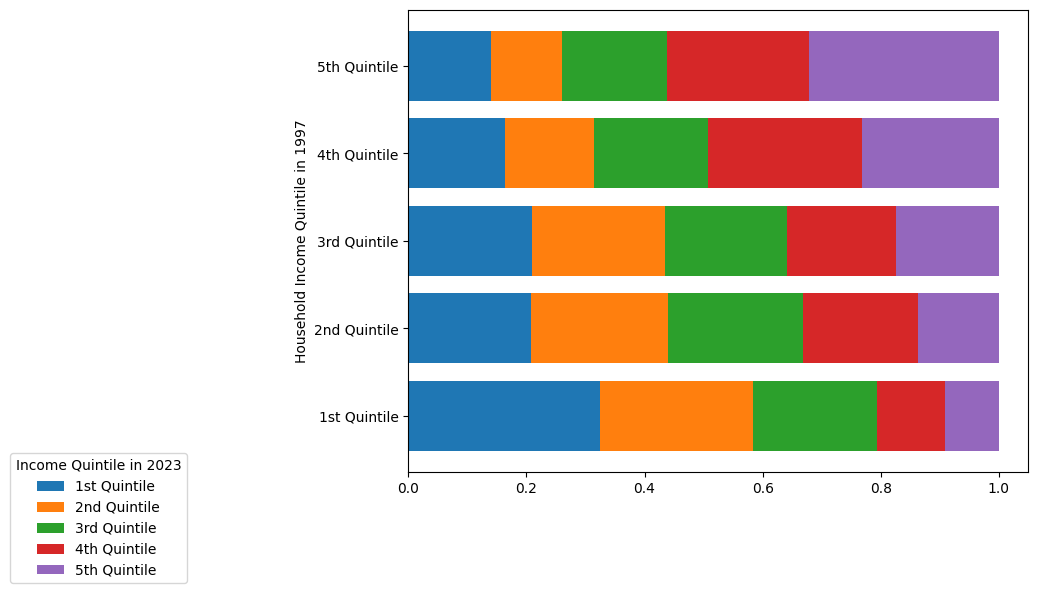

In [26]:
plot_df = incomes_df.copy()

plot_df = (
    plot_df
        # represantative sub-sample
        .loc[plot_df['sample'].eq('Cross-sectional') &
             # hh income in 1997 is parent income  
             plot_df['hh_yinc_source_1997'].eq('Parent') &
             # non-missing observations for both income variables 
             plot_df['hh_yinc_1997'].notna() & 
             plot_df['yinc_2023'].notna(), 
             # selecting the variables
             ['hh_yinc_1997_Q', 'yinc_2023_Q']].copy()
)

conditioning_var = 'hh_yinc_1997_Q'
outcome_var = 'yinc_2023_Q'

# conditional relative frequencies
plot_df = (
    plot_df
        # within each of the conditioning variable (parent income quintile)
        .groupby(conditioning_var)
        # for each value of child income quintile
        # proportion of observations
        .value_counts(subset=[outcome_var], normalize=True)
        .reset_index()
        .sort_values(by=[conditioning_var, outcome_var])
        .reset_index(drop=True)


)

# computing conditional cumulative proportions
# within each parent quintile
# for each child quintile
plot_df['cumulative_proportion_below'] = (
    plot_df
        .groupby(conditioning_var)['proportion']
        .cumsum() 
        - plot_df['proportion']
)

# collecting distinct values of the outcome variable
outcome_var_categories = plot_df[outcome_var].sort_values().drop_duplicates().copy().to_list()

fig, ax = plt.subplots(figsize = (8,6))

for outcome_var_cat in outcome_var_categories:
    plot_df_cat = plot_df.loc[plot_df[outcome_var].eq(outcome_var_cat),:].sort_values(conditioning_var).reset_index(drop=True)

    ax.barh(y=plot_df_cat[conditioning_var],
            left=plot_df_cat['cumulative_proportion_below'],
            width=plot_df_cat['proportion'],
            label=outcome_var_cat)

ax.legend(title='Income Quintile in 2023', loc ='center', bbox_to_anchor = (-0.5,-0.1))
ax.set_ylabel('Household Income Quintile in 1997')



If child income-quintile was `statistically independent` from parent income-quintile, then we should see:
$$
\mathbb{P}[\text{child income quintile} | \text{parent income quintile}] = 20\%
$$

#### Conditional distribution under independence

Let us artificially reassign child income quintile to see how the distribution would look like if child income quintile was independent from parent income quintile:

Text(0, 0.5, 'Household Income Quintile in 1997')

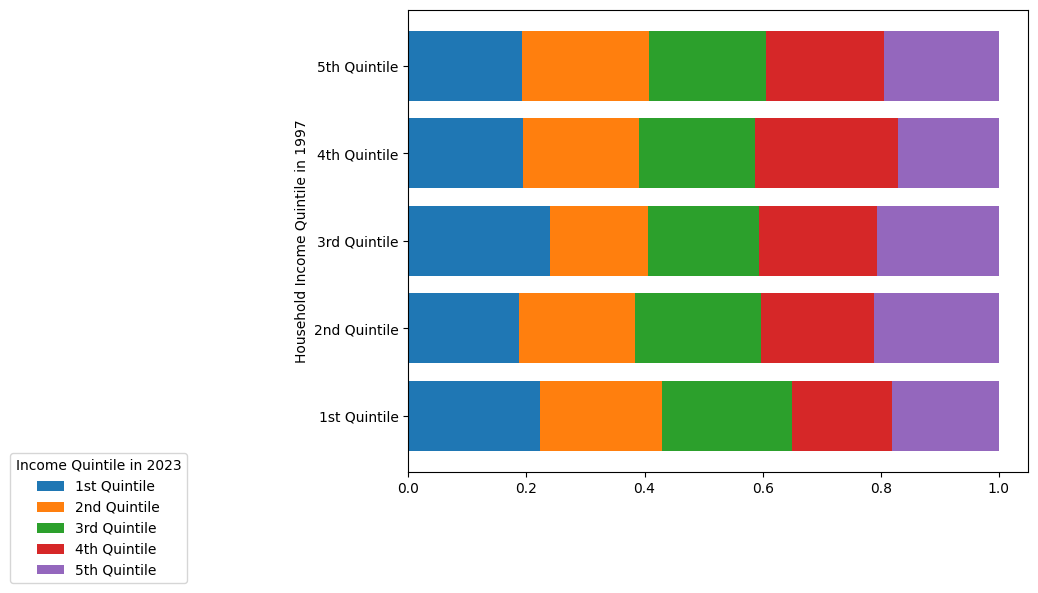

In [ ]:
# Simulation -> complete independence

rng = np.random.default_rng(798312)

plot_df = incomes_df.copy()

plot_df = (
    plot_df
        # represantative sub-sample
        .loc[plot_df['sample'].eq('Cross-sectional') &
             # hh income in 1997 is parent income  
             plot_df['hh_yinc_source_1997'].eq('Parent') &
             # non-missing observations for both income variables 
             plot_df['hh_yinc_1997'].notna() & 
             plot_df['yinc_2023'].notna(), 
             # selecting the variables
             ['hh_yinc_1997_Q', 'yinc_2023_Q']].copy()
)

# CREATING ARTIFICIAL DATA
# randomly reassign the income quintile around age 40
plot_df['yinc_2023_Q'] = rng.permutation(plot_df['yinc_2023_Q'])

conditioning_var = 'hh_yinc_1997_Q'
outcome_var = 'yinc_2023_Q'

# conditional relative frequencies
plot_df = (
    plot_df
        # within each of the conditioning variable (parent income quintile)
        .groupby(conditioning_var)
        # for each value of child income quintile
        # proportion of observations
        .value_counts(subset=[outcome_var], normalize=True)
        .reset_index()
        .sort_values(by=[conditioning_var, outcome_var])
        .reset_index(drop=True)


)

# computing conditional cumulative proportions
# within each parent quintile
# for each child quintile
plot_df['cumulative_proportion_below'] = (
    plot_df
        .groupby(conditioning_var)['proportion']
        .cumsum() 
        - plot_df['proportion']
)

# collecting distinct values of the outcome variable
outcome_var_categories = plot_df[outcome_var].sort_values().drop_duplicates().copy().to_list()

fig, ax = plt.subplots(figsize = (8,6))

for outcome_var_cat in outcome_var_categories:
    plot_df_cat = plot_df.loc[plot_df[outcome_var].eq(outcome_var_cat),:].sort_values(conditioning_var).reset_index(drop=True)

    ax.barh(y=plot_df_cat[conditioning_var],
            left=plot_df_cat['cumulative_proportion_below'],
            width=plot_df_cat['proportion'],
            label=outcome_var_cat)

ax.legend(title='Income Quintile in 2023', loc ='center', bbox_to_anchor = (-0.5,-0.1))
ax.set_ylabel('Household Income Quintile in 1997')



##### Gender Pay Gaps

Overall mean gender pay gap:

In [ ]:
gpg_df = incomes_df.copy() 
gpg_df = gpg_df.loc[gpg_df['sample'].eq('Cross-sectional') & gpg_df['yhours_2023'].ge(1800) & gpg_df['yinc_2023'].notna() & gpg_df['yhours_2023'].notna() & gpg_df['yhours_2023'].ne(0),:]

gpg_df['hinc_2023'] = gpg_df['yinc_2023'] / gpg_df['yhours_2023']

hinc_2023_avg_female = gpg_df.loc[gpg_df['gender'].eq('Female'), 'hinc_2023'].mean()
hinc_2023_avg_male = gpg_df.loc[gpg_df['gender'].eq('Male'), 'hinc_2023'].mean()

overall_gpg = (hinc_2023_avg_female - hinc_2023_avg_male)/max(hinc_2023_avg_female, hinc_2023_avg_male)

overall_gpg

Median gender pay gap:

In [ ]:
hinc_2023_med_female = gpg_df.loc[gpg_df['gender'].eq('Female'), 'hinc_2023'].median()
hinc_2023_med_male = gpg_df.loc[gpg_df['gender'].eq('Male'), 'hinc_2023'].median()

overall_med_gpg = (hinc_2023_med_female - hinc_2023_med_male)/max(hinc_2023_med_female, hinc_2023_med_male)

overall_med_gpg


Gender pay gaps by education groups:

In [ ]:
degree_var = 'educ_cat'
df = gpg_df.copy()

df = df.groupby(['gender', degree_var]).agg(hinc_mean = ('hinc_2023', 'mean'), count=('hinc_2023', 'size')).reset_index().sort_values(['gender', degree_var]).reset_index(drop=True).copy()
df_female = df.loc[df['gender'].eq('Female'), [degree_var, 'hinc_mean', 'count']].rename(columns={'hinc_mean': 'hinc_mean_female',
                                                                                                'count': 'count_female'})
df_male = df.loc[df['gender'].eq('Male'), [degree_var, 'hinc_mean', 'count']].rename(columns={'hinc_mean': 'hinc_mean_male',
                                                                                                'count': 'count_male'})
df_wide = pd.merge(left = df_female, right=df_male, on=degree_var)
df_wide = df_wide.sort_values(degree_var)
df_wide

In [ ]:
degree_order = df_wide[degree_var].dropna().sort_values().unique()
degree_ranks = np.arange(len(degree_order))
degree_to_y = {degree_order[i]: i for i in degree_ranks}

df_wide['y'] = df_wide[degree_var].map(degree_to_y).astype(float)

fig, ax = plt.subplots(figsize=(6,6))

dodge = 0.2

ax.barh(y=df_wide['y'] + dodge, height=0.3, width=df_wide['count_female'], alpha=0.5, label= 'Female (count)')
ax.scatter(y=df_wide['y'] + dodge, x=df_wide['hinc_mean_female'], label='Female (wage)')

ax.barh(y=df_wide['y'] - dodge, height=0.3, width=df_wide['count_male'], alpha=0.5, label= 'Male (count)')
ax.scatter(y=df_wide['y'] - dodge, x=df_wide['hinc_mean_male'], label='Male (wage)')


ax.set_yticks(ticks=degree_ranks, labels=degree_order)
#ax.set_yticklabels()

ax.legend()




